# 1. Single Linear Regression - Video Game Sales
## (Using one feature to predict a continuous numerical target)
## https://www.kaggle.com/datasets/ulrikthygepedersen/video-games-sales

In [759]:
#Import Statments
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

from sklearn.linear_model import (
    LinearRegression,
    Ridge, 
    Lasso,
    ElasticNet
)

#### **General Utility Functions** ####

In [760]:

data_set_name = ''
target_label = ''

def DisplayTable(df_target, table_title=None, max_cell_length=30):

    if df_target.empty:
        print(f"No data to display{': ' + table_title if table_title else ''}")
        return

    n_rows, n_cols = df_target.shape

    fig_height = (n_rows + 1) * 0.35
    if table_title:
        fig_height += 0.4
    
    fig, ax = plt.subplots(figsize=(n_cols * 1.5, fig_height))
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Format floats and truncate long text
    cell_text = []
    for row in df_target.values:
        new_row = []
        for val in row:
            if isinstance(val, (float, int)) and not isinstance(val, bool):
                new_row.append(f"{val:.2f}")
            else:
                s = str(val)
                if len(s) > max_cell_length:
                    s = s[:max_cell_length - 3] + '...'
                new_row.append(s)
        cell_text.append(new_row)

    table = ax.table(
        cellText=cell_text,
        colLabels=df_target.columns,
        cellLoc='center',
        loc='upper center',
        bbox=[0, 0, 1, 1]
    )

    # Bold column headers and set header background
    for col in range(n_cols):
        table[(0, col)].set_facecolor('#4a90d9')
        table[(0, col)].set_text_props(color='white', fontweight='bold')

    # Light blue background for data cells
    for row in range(1, n_rows + 1):
        for col in range(n_cols):
            table[(row, col)].set_facecolor('#d4e6f1')

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.auto_set_column_width(col=list(range(n_cols)))

    if table_title is not None:
        fig.suptitle(table_title, fontweight='bold', fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.95] if table_title else [0, 0, 1, 1])

    plt.show()
    plt.close(fig)
    
def PrintDataFrameStatus(df_target):
    # Print Stats
    print("***********************************")
    print("Description Stats")
    print("***********************************")
    print()

    # Capture for Table plot
    df_stats = df_target.describe(include='all').T.reset_index()
    df_stats.rename(columns={'index': 'Feature'}, inplace=True)
    print(df_stats)
    print()

    # Print df Column Info
    print("***********************************")
    print("Basic Info of imported data set")
    print("***********************************")
    print()

    df_info = pd.DataFrame({
                            'Feature': df_target.columns,
                            'Non-Null Count': df_target.notna().sum().values,
                            'Null Count': df_target.isna().sum().values,
                            'Dtype': df_target.dtypes.values
                            }).reset_index(drop=True)

    print(f'Dataset Shape:{df_target.shape}')
    df_shape = pd.DataFrame({'Rows': [df_target.shape[0]], 'Columns': [df_target.shape[1]]})
    print()

    print('Do we have any features with null values?:')
    print(df_target.isnull().any().any())
    print()

    print('Feature Columns with that have null values:')
    print(df_target.isnull().sum()[df_target.isnull().sum() > 0])

    # Capture for Table plot
    cols_to_plot = df_target.select_dtypes(exclude=['number']).columns
    missing = df_target[cols_to_plot].isnull().sum()
    missing = missing[missing > 0]
    df_missing = pd.DataFrame({
                                'Feature': missing.index,
                                'Missing Count': missing.values,
                                'Missing %': (missing.values / len(df_target) * 100).round(2)
                                }).reset_index(drop=True)
    print()

    print('Do we have any features with nan values?:')

    cols_to_plot = df_target.select_dtypes(include=['number']).columns
    nan_vals = df_target[cols_to_plot].isna().sum()
    nan_vals = nan_vals[nan_vals > 0]
    # Capture for Table plot
    df_nan = pd.DataFrame({
                            'Feature': nan_vals.index,
                            'NaN Count': nan_vals.values,
                            'NaN %': (nan_vals.values / len(df_target) * 100).round(2)
                        }).reset_index(drop=True)
    print(df_target.isna().any().any())

    # Sum up the number of missing features per row
    missing_per_row = df_target.isna().sum(axis=1)  # count missing per row
    missing_counts = missing_per_row.value_counts().sort_index()  # count rows for each missing count

    df_missingfeature_rowcounts = pd.DataFrame({
        'Missing Features': missing_counts.index,
        'Row Count': missing_counts.values
    })

    print("***********************************")
    print("First 20 rows of Data")
    print("***********************************")
    print()
    print(df_target.head(20))
    print()

    print("***********************************")
    print("First 20 rows of Random Sample Data")
    print("***********************************")
    print()
    df_randomsample = df_target.sample(n=20)
    print(df_target.sample(20))
    print()

    #
    # Display Results in Pretty Tables
    #
    print('Display Analysis Results in Tables')
    DisplayTable(df_stats, f'{data_set_name} Description Statistics')
    print()
    DisplayTable(df_info, f'{data_set_name} Basic Information')
    print()
    DisplayTable(df_shape, f'{data_set_name} Dataset Shape')
    print()
    DisplayTable(df_missing, f'{data_set_name} Missing Categorical (String) Data')
    print()
    DisplayTable(df_nan, f'{data_set_name} Missing Numeric Data')
    print()
    DisplayTable(df_missingfeature_rowcounts, f'{data_set_name} Summary of Missing Feature Row Counts')
    print()    
    DisplayTable(df_randomsample, f'{data_set_name} Random Data Sample')
    print()

def ExamineCategoricalFeature(df_target, feature_name):
    n_times = df_target[feature_name].nunique()
    values = df_target[feature_name].unique()
    print(f'Feature:: {feature_name} -- There are: {n_times} unique times (times of day)')
    print(values)
    print()


def ExamineCategoricalFeatures(df_target):

    categorical_features = df_target.select_dtypes(exclude=['number']).columns.tolist()

    for i, feature_name in enumerate(categorical_features):
        ExamineCategoricalFeature(df_target, feature_name)

    print()
    print()        

def DisplayNumericFeatureHistgorams(df_target, feature_columns = None, target_label=None, plot_title=None, display_statistics=True, batch_size=15):

    cols_to_plot = []
    statistics = []
    
    if feature_columns is None:
        cols_to_plot = df_target.select_dtypes(include=['number']).columns
    else:
        cols_to_plot = feature_columns

    if target_label is not None:
        cols_to_plot = cols_to_plot.drop(target_label).tolist()
    
    total_cols = len(cols_to_plot)
    total_batches = (total_cols + batch_size - 1) // batch_size

    # Process in batches
    for batch_num, batch_start in enumerate(range(0, total_cols, batch_size), 1):
        batch_cols = cols_to_plot[batch_start:batch_start + batch_size]
        number_of_cols = len(batch_cols)

        ncols = min(number_of_cols, 3)  # max 3 per row, but no more than n
        nrows = (number_of_cols + ncols - 1) // ncols

        # I need a 3 column plot
        fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
        if number_of_cols == 1:
            axes = [axes]
        else:
            axes = axes.flatten()

        # Iterate over each numeric column and plot a historbram
        for i, col in enumerate(batch_cols):

            try:
                sns.histplot(data=df_target, x=col, ax=axes[i], kde=True)

                axes[i].set_xlabel(col, fontweight='bold')
                axes[i].set_ylabel('Count', fontweight='bold')
                data = df_target[col]

                if display_statistics == True:

                    min_val = data.min()
                    max_val = data.max()
                    range_val = data.max() - data.min()
                    mean_val = data.mean()
                    median_val = data.median()
                    mode_val = data.mode().tolist()
                    std_val = data.std()
                    quantile_val = data.quantile([0.25, 0.5, 0.75, 0.90, 0.95]).tolist()
                    skew_val = data.skew()
                    kurtosis_val = data.kurtosis()

                    stats = {
                        'Feature': col,
                        'Min': min_val,
                        'Max': max_val,
                        'Mean': mean_val,
                        'Median': median_val,
                        'Mode': mode_val,
                        'Std': std_val,
                        'Range': range_val,
                        'Quantile': quantile_val,
                        'Skew': skew_val,
                        'Kurtosis': kurtosis_val
                    }            

                    statistics.append(stats)

                    # print(f'Min Value: {min_val:.3f}')
                    # print(f'Max Value: {max_val:.3f}')
                    # print(f'Mean Value: {mean_val:.3f}')
                    # print(f'Median Value: {median_val:.3f}')
                    # print(f'Mode Value: {mode_val}')
                    # print(f'Standard Deviation: {std_val:.3f}')
                    # print(f'Range Value = {range_val:.3f}')
                    # print(f'Quantile Value = {quantile_val}')
                    # print(f'Skew Value: {skew_val:.3f}')
                    # print(f'Kurtosis Value: {kurtosis_val:.3f}')            

                    axes[i].set_title(f'{col}\nmean={mean_val:.2f}, med={median_val:.2f}, std={data.std():.2f}', fontweight='bold')

                    # Vertical lines for mean and median, shaded std
                    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
                    axes[i].axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')            
                    axes[i].axvspan(mean_val - std_val, mean_val + std_val, alpha=0.2, color='orange', label=f'±1 Std')

                else:
                    axes[i].set_title(f'{col}', fontweight='bold')
                
                # Tick labels in bold
                axes[i].tick_params(axis='both', labelsize=10)
                for label in axes[i].get_xticklabels() + axes[i].get_yticklabels():
                    label.set_fontweight('bold')

            except Exception as ex:
                print(f"Warning: Unexpected error - {ex}")
                continue

        # Hide the blank/empty graphs
        for j in range(number_of_cols, len(axes)):
            fig.delaxes(axes[j])

        # Make plots more readable and add space
        title = None
        # Make plots more readable and add space
        title = None
        if plot_title is None:
            title = f'Histograms for Numeric Features of {data_set_name} (Batch {batch_num}/{total_batches})'
        else:
            title = f'Histograms for Numeric Features of {data_set_name} :: {plot_title} (Batch {batch_num}/{total_batches})'

        plt.suptitle(title, fontweight='bold')

        plt.suptitle(title)
        plt.subplots_adjust(top=0.92)  

        plt.tight_layout(h_pad=5)
        plt.show()
        plt.close(fig)

        print()
        print()

    if display_statistics == True:
        df_statistics = pd.DataFrame(statistics)
        DisplayTable(df_statistics, 'Numeric Features Statistics')

def PlotBoxPlotsToViewDistributions(df_target, feature_columns = None, target_label=None, plot_title=None, batch_size=15):

    cols_to_plot = []
    if feature_columns is None:
        cols_to_plot = df_target.select_dtypes(include=['number']).columns
    else:
        cols_to_plot = feature_columns

    if target_label is not None:
        cols_to_plot = cols_to_plot.drop(target_label).tolist()
    
    total_cols = len(cols_to_plot)
    total_batches = (total_cols + batch_size - 1) // batch_size

    # Process in batches
    for batch_num, batch_start in enumerate(range(0, total_cols, batch_size), 1):
        batch_cols = cols_to_plot[batch_start:batch_start + batch_size]
        number_of_cols = len(batch_cols)

        ncols = min(number_of_cols, 3)  # max 3 per row, but no more than n
        nrows = (number_of_cols + ncols - 1) // ncols

        # I need a 3X4 plot to display 10 histograms
        fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
        if number_of_cols == 1:
            axes = [axes]
        else:
            axes = axes.flatten()

        #Iterate over each numeric column and plot a historgram
        for i, col in enumerate(batch_cols):

            sns.boxplot(data=df_target, y=col, ax=axes[i])    
            axes[i].set_title(col, fontweight='bold')

            # Optional: Add count of outliers
            Q1 = df_target[col].quantile(0.25)
            Q3 = df_target[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            outlier_count = len(df_target[(df_target[col] < lower) | 
                                                (df_target[col] > upper)])
            axes[i].text(0.5, 0.95, f'Outliers: {outlier_count}', 
                        transform=axes[i].transAxes, ha='center', fontsize=9, fontweight='bold')

        # Hide the blank/empty graphs
        for j in range(number_of_cols, len(axes)):
            fig.delaxes(axes[j])        

        # Make plots more readable and add space
        title = None
        if plot_title is None:
            title = f'BoxPlots for Features of {data_set_name} (Batch {batch_num}/{total_batches})'
        else:
            title = f'BoxPlots for Features of {data_set_name} :: {plot_title} (Batch {batch_num}/{total_batches})'

        plt.suptitle(title, fontweight='bold')
        plt.tight_layout(rect=[0, 0, 1, 0.90])  # Leave space at top
        #plt.subplots_adjust(top=0.92)        

        # Make plots more readable and add space
        plt.tight_layout(h_pad=5)
        plt.show()
        plt.close(fig)

        print()
        print()        


def DisplayBarCountPlotsOfCategoricFeatures(df_target, feature_columns = None, target_label=None, plot_title=None, display_bar_labels=True, batch_size=15):

    cols_to_plot = []
    if feature_columns is None:
        cols_to_plot = df_target.select_dtypes(include=['object']).columns
    else:
        cols_to_plot = feature_columns

    if target_label is not None:
        cols_to_plot = cols_to_plot.remove(target_label)
    
    total_cols = len(cols_to_plot)
    total_batches = (total_cols + batch_size - 1) // batch_size

    # Process in batches
    for batch_num, batch_start in enumerate(range(0, total_cols, batch_size), 1):
        batch_cols = cols_to_plot[batch_start:batch_start + batch_size]
        number_of_cols = len(batch_cols)

        ncols = min(number_of_cols, 3)  # max 3 per row, but no more than n
        nrows = (number_of_cols + ncols - 1) // ncols

        # I need a 3 column plot
        fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
        if number_of_cols == 1:
            axes = [axes]
        else:
            axes = axes.flatten()

        # Iterate over each numeric column and plot a historbram
        for i, col in enumerate(batch_cols):
            
            sns.countplot(data=df_target, x=col, ax=axes[i])

            axes[i].set_title(col, fontweight='bold')
            axes[i].set_xlabel(col, fontweight='bold')
            axes[i].set_ylabel('Count', fontweight='bold')

            if display_bar_labels == True:
                # Add count labels on bars
                axes[i].bar_label(axes[i].containers[0], label_type='center', fontsize=8, rotation=90, fmt='%d', color='white')

            # Tick labels in bold
            axes[i].tick_params(axis='both', labelsize=10)
            for label in axes[i].get_xticklabels() + axes[i].get_yticklabels():
                label.set_fontweight('bold')            

        # Hide the blank/empty graphs
        for j in range(number_of_cols, len(axes)):
            fig.delaxes(axes[j])

        title = None
        if plot_title is None:
            title = f'Heat Maps for Correlated Features of {data_set_name}'
        else:
            title = plot_title
        
        # Make plots more readable and add space
        plt.suptitle(title, fontweight='bold')
        plt.subplots_adjust(top=0.92)  
        
        plt.tight_layout(h_pad=5)
        plt.show()
        plt.close(fig)

        print()
        print()    

def DisplayCorrelationInfo(df_target, feature_columns = None, target_label=None, plot_title=None):
    # omit categorical column region
    df_corr = df_target.drop(columns=[target_label]).corr()
    # print(type(df_corr))
    # print(df_corr)

    # Create heatmap
    plt.figure(figsize=(15, 15))
    sns.heatmap(df_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=0.5)
    plt.title('Correlation Matrix', fontsize=16, fontweight='bold')

    title = None
    if plot_title is None:
        title = f'Heat Maps for Correlation Matrix for Features of {data_set_name}'
    else:
        title = f'Bar Count Plots for Categoric Features of {data_set_name}'        

    plt.tight_layout()
    plt.show()

    print()
    print()

    # Table
    DisplayTable(df_corr)
    print()
    print()

#
# Create Linear Regression
#

def RunLinearRegression(df_target, target_label):

    X = df_target.drop(target_label, axis=1)  # DataFrame
    y = df_target[target_label]               # Series

    #
    # Split Data into Training/Test => 80/20
    #
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=315)


    linear_regression_model = LinearRegression()

    fit_result = linear_regression_model.fit( 
                                                X_train,
                                                y_train
                                            )

    train_predictions = linear_regression_model.predict(X_train)
    train_rmse = root_mean_squared_error(y_train, train_predictions)
    print(f'Training RMSE: {train_rmse:.4f}')
    print()

    test_predictions = linear_regression_model.predict(X_test)
    test_rmse = root_mean_squared_error(y_test, test_predictions)
    print(f'Testing RMSE: {test_rmse:.4f}')
    print()
    print()

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
    plt.suptitle('Linear Regressions Results', fontweight='bold')

    #
    # Train Data
    #
    # Plots
    axes[0].scatter(y_train, train_predictions, alpha=0.5)
    min_val = min(y_train.min(), train_predictions.min())
    max_val = max(y_train.max(), train_predictions.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r', linewidth=5)

    # LOWESS smooth line - method for showing true relationship as predictions trend against actual
    smoothed = lowess(train_predictions, y_train, frac=0.3)
    axes[0].plot(smoothed[:, 0], smoothed[:, 1], color='springgreen', linewidth=3)

    # Labels
    axes[0].set_title('Predicted vs Actual Values for Training Data', fontweight='bold')
    axes[0].set_xlabel('Actual Values')
    axes[0].set_ylabel('Predicted Values')
    axes[0].legend()

    #
    # Test Data
    #
    # Plots
    axes[1].scatter(y_test, test_predictions, alpha=0.5)
    min_val = min(y_test.min(), test_predictions.min())
    max_val = max(y_test.max(), test_predictions.max())
    axes[1].plot([min_val, max_val], [min_val, max_val], 'r', linewidth=5)

    # LOWESS smooth line
    smoothed = lowess(test_predictions, y_test, frac=0.3)
    axes[1].plot(smoothed[:, 0], smoothed[:, 1], color='springgreen', linewidth=3)

    # Labels
    axes[1].set_title('Predicted vs Actual Values for Test Data', fontweight='bold')
    axes[1].set_xlabel('Actual Values')
    axes[1].set_ylabel('Predicted Values')
    axes[1].legend()
    
    # Make plots more readable and add space
    plt.tight_layout(h_pad=5)
    plt.show()   
    print()
    print()


    # Plot Residuals
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
    plt.suptitle('Linear Fit Residuals', fontweight='bold')

    #
    # Train Data
    #
    residuals_lr = y_train - train_predictions
    axes[0].set_title('LinearRegression Training Data: Fit Residuals')
    axes[0].scatter(train_predictions, residuals_lr, c='black', s=1)
    axes[0].axhline(y=0, color='r')
    axes[0].set_xlabel('Predicted values')
    axes[0].set_ylabel('Residuals')
    axes[0].grid(True, alpha=0.3)

    #
    # Test Data
    #
    residuals_lr = y_test - test_predictions
    axes[1].set_title('LinearRegression Test Data: Fit Residuals')
    axes[1].scatter(test_predictions, residuals_lr, c='black', s=1)
    axes[1].axhline(y=0, color='r')
    axes[1].set_xlabel('Predicted values')
    axes[1].set_ylabel('Residuals')
    axes[1].grid(True, alpha=0.3)

    # Make plots more readable and add space
    plt.tight_layout(h_pad=5)
    plt.show()   
    print()
    print()

    #
    #  Plot Linear Coefficients
    #
    print('----------------------------------------------')
    print('Model Coefficients')
    print(fit_result.coef_)
    print('----------------------------------------------')
    print()

    coefficients = pd.Series(linear_regression_model.coef_, index=X_train.columns)
    coefficients_sorted = coefficients.sort_values()

    plt.figure(figsize=(10, 8))
    coefficients_sorted.plot(kind='barh')
    plt.xlabel('Coefficient Value')
    plt.ylabel('Feature')
    plt.title('Linear Regression Coefficients')
    plt.axvline(x=0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.show()

    print()
    print(f'Training RMSE: {train_rmse:.4f}')
    print(f'Testing RMSE: {test_rmse:.4f}')
    print()

    return linear_regression_model    

In [761]:
# Loading video game sales data
df_VideoGame = pd.read_csv('video_games_sales.csv')

# Visualizing the dataframe
df_VideoGame

data_set_name = 'Video Game Sales'
target_label = 'global_sales'

## Let's see if we can use a subset of this data to predict the target variable: global_sales

#### **Before Starting, Let's print out some general statics/info about the dataset** ####

In [762]:
#PrintDataFrameStatus(df_VideoGame)

In [763]:
# Exctracting Features from the original df_VideoGame Dataset
df_VideoGameFeatureSubset = df_VideoGame[['platform', 'year', 'genre', 'publisher','na_sales', 'global_sales']]

# Look at and see what the null features are to start!!
# df_VideoGameFeatureSubset.isnull().sum()
# Dropping null values from the dataset
df_VideoGameFeatureSubset.dropna(inplace=True)
df_VideoGameFeatureSubset.isnull().sum()

C:\Users\jxbma\AppData\Local\Temp\ipykernel_19976\4025918235.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_VideoGameFeatureSubset.dropna(inplace=True)


platform        0
year            0
genre           0
publisher       0
na_sales        0
global_sales    0
dtype: int64

### **Comments/Corrections**

**Dropping of rows with null values**

1. **Why would you drop rows containing null features?**
   - It is a bad thing to drop rows that having missing data. This can (and will) affect the results throughout the analysis and model building
   - If you are going to do this (which you shouldn't), why would you do it without first checking to see how null values you actually have?

2. **Why are you dropping features?**
   - Dropping features is generally a bad thing, why are you dropping features right from the get go, without further analysis?
   - At this point of the process you have done zero analysis on the feature set and you are making arbitrary decisions about the data. (**DON'T**)

3. **All your analysis moving forward will be flawed.**

In [764]:
# Initialize the labelencoder object
le_videogame = LabelEncoder()

# Save the unencoded feature platform (In case you want to decode later)
df_VideoGame_decoded_platform = df_VideoGameFeatureSubset['platform']

# Override the original platform feature with the label encoded feature
df_VideoGameFeatureSubset['platform'] = le_videogame.fit_transform(df_VideoGameFeatureSubset['platform'])

# Print out the decoded series, platform
df_VideoGame_decoded_platform

# Examine Categoric Features and their value sets
#ExamineCategoricalFeatures(df_VideoGame)

C:\Users\jxbma\AppData\Local\Temp\ipykernel_19976\1272788320.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_VideoGameFeatureSubset['platform'] = le_videogame.fit_transform(df_VideoGameFeatureSubset['platform'])


0        Wii
1        NES
2        Wii
3        Wii
4         GB
        ... 
16593    GBA
16594     GC
16595    PS2
16596     DS
16597    GBA
Name: platform, Length: 16291, dtype: object

### Comments/Corrections

**Label Encoding**

1. **Not entirely clear why you would be doing LabelEncoding() here...**
   - Not sure why you are doing LabelEncoding() here and what your intent is.
   - You create it and you never actually use it.
   - Why did you choose "**platform**" feature? Seems kind of random.
   - **LabelEncoding()** would be more suited is more suited to **Target Variables** - what we're ultimately trying to predict.
   - The better course of action here is to identify categorical features (in this case: platform, genre, publisher [not sure about name - given there over 500 unique instances])

In [765]:
#
# genre - Are these all valid genres?
#
n_values = df_VideoGameFeatureSubset['genre'].nunique()
values = df_VideoGameFeatureSubset['genre'].unique()
print(f'There are: {n_values} unique states (Austrlian States)')
print(values)
print()


# Save the unencoded feature genre (In case you want to decode later)
df_VideoGame_decoded_genre = df_VideoGameFeatureSubset['genre']

# Override the original genre feature with the label encoded feature
df_VideoGameFeatureSubset['genre'] = le_videogame.fit_transform(df_VideoGameFeatureSubset['genre'])

# Print out the decoded series, genre
df_VideoGame_decoded_genre

There are: 12 unique states (Austrlian States)
['Sports' 'Platform' 'Racing' 'Role-Playing' 'Puzzle' 'Misc' 'Shooter'
 'Simulation' 'Action' 'Fighting' 'Adventure' 'Strategy']



C:\Users\jxbma\AppData\Local\Temp\ipykernel_19976\3786422853.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_VideoGameFeatureSubset['genre'] = le_videogame.fit_transform(df_VideoGameFeatureSubset['genre'])


0              Sports
1            Platform
2              Racing
3              Sports
4        Role-Playing
             ...     
16593        Platform
16594         Shooter
16595          Racing
16596          Puzzle
16597        Platform
Name: genre, Length: 16291, dtype: object

In [766]:
# Save the unencoded feature publisher (In case you want to decode later)
df_VideoGame_decoded_publisher = df_VideoGameFeatureSubset['publisher']

# Override the original publisher feature with the label encoded feature
df_VideoGameFeatureSubset['publisher'] = le_videogame.fit_transform(df_VideoGameFeatureSubset['publisher'])

# Print out the decoded series, publisher
df_VideoGame_decoded_publisher

C:\Users\jxbma\AppData\Local\Temp\ipykernel_19976\109776527.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_VideoGameFeatureSubset['publisher'] = le_videogame.fit_transform(df_VideoGameFeatureSubset['publisher'])


0          Nintendo
1          Nintendo
2          Nintendo
3          Nintendo
4          Nintendo
            ...    
16593         Kemco
16594    Infogrames
16595    Activision
16596      7G//AMES
16597       Wanadoo
Name: publisher, Length: 16291, dtype: object

### **Comments/Corrections**

**Label Encoding for publisher**

1. **Same comments apply from the previous section**
   - Not sure why you are doing LabelEncoding() here and what your intent is.

In [767]:
# Feel free to uncomment the chart below, may take a little while to output though
# sns.pairplot(df_VideoGameFeatureSubset.drop('global_sales', axis=1), kind='kde')

# Full Feature Set
#df_randomsample = df_VideoGame.sample(n=1000, random_state=42)
#sns.pairplot(df_VideoGameFeatureSubset.drop('global_sales', axis=1), kind='kde')
#sns.pairplot(df_randomsample.drop('global_sales', axis=1), kind='kde')


### **Comments/Corrections**

**Pair Plots**

1. **Why are you running this against a subset of features?**
   - It's like some presumptions have been made about the features, their relationships and importance (do you somehow have additional insight from management?)
   - This will lead you to quite possibly invalid analysis, planning for model building and model predictions/interpretrations

2. **Why not use full feature set?**
   - Use the full feature set to get a clearer view of features and their relatioships.
   - To improve on the performance of this step, use a smaller random sample size. There's no need to use all 16K+ rows. 
   - You are just just looking for the existance of patterns, not precise analytics. A smaller random dataset will produce the same general patterns.
   - Sample size with full feature set took 40 sec to run as opposed to 9 min for subset of features against the full dataset.


In [768]:
# View the labelencoded dataframe
df_VideoGameFeatureSubset

,platform,year,genre,publisher,na_sales,global_sales
0,26,2006.0,10,359,41.49,82.74
1,11,1985.0,4,359,29.08,40.24
2,26,2008.0,6,359,15.85,35.82
3,26,2009.0,10,359,15.75,33.00
4,5,1996.0,7,359,11.27,31.37
...,...,...,...,...,...,...
16593,6,2002.0,4,269,0.01,0.01
16594,7,2003.0,8,241,0.01,0.01
16595,16,2008.0,6,21,0.00,0.01
16596,4,2010.0,5,8,0.00,0.01


In [769]:
# Normailze platform, year, genre, and publisher
# mm_scaler = MinMaxScaler(feature_range=(-1, 1))

# df_VideoGameFeatureSubset[['platform', 'year', 'genre', 'publisher']] = mm_scaler.fit_transform(df_VideoGameFeatureSubset[['platform', 'year', 'genre', 'publisher']])
# df_VideoGameFeatureSubset


df_randomsample = df_VideoGame.sample(n=1000, random_state=42)
#PrintDataFrameStatus(df_VideoGame)
#sns.pairplot(df_VideoGameFeatureSubset.drop('global_sales', axis=1), kind='kde')
#sns.pairplot(df_randomsample.drop('global_sales', axis=1), kind='kde')
# DisplayNumericFeatureHistgorams(df_randomsample, target_label='global_sales', plot_title='Histograms of Numeric Features', display_statistics=True, batch_size=15)
# print()
# PlotBoxPlotsToViewDistributions(df_randomsample, target_label='global_sales', plot_title='Box Plots of Numeric Features')

### **Feature Normalization**

**MinMaxScaler**

1. **Why are you normalizing without analysis**
   - You're making arbitrary decisions on a normalization technique when you haven't visually examined the data through histograms/boxplots
   - Examine the data more thoroughly, (is there skewness.., yes there is!!!)
   - Use a variety of normalization techniques and choose the best performing (R² and skewness)
   - And there are outliers...
   - How are you going to deal with the outliers?
2. **Why not use full feature set?**
   - Again, continuing with the theme
3. **Scaling and Data Leakage**
   - Scaling is being applied against the entire feature set
   - To avoid leakge, scaling should be fit against the training data and then have the transform performed against test/train
      - X_train_scaled = scaler.transform(X_train)
      - X_test_scaled = scaler.transform(X_test)
   - Then use these when running the model.


In [770]:
# Create a pairplot for the normalized data, columns_to_manipulate, use kde for the kind
#sns.pairplot(df_VideoGameFeatureSubset, kind='kde')


# Again, use a smaller random sample and you'll see the patterns

# Feel free to uncomment the chart below, may take a little while to output though
# df_randomsample = df_VideoGameFeatureSubset.sample(n=1000, random_state=42)
# sns.pairplot(df_randomsample, kind='kde')

# Full Feature Set
#df_randomsample = df_VideoGame.sample(n=1000, random_state=42)
#sns.pairplot(df_VideoGameFeatureSubset.drop('global_sales', axis=1), kind='kde')
#sns.pairplot(df_randomsample.drop('global_sales', axis=1), kind='kde')

### **Comments/Corrections**

**Pair Plots**

1. **Same comments apply from Pair Plots section above**   

In [771]:
# Save Checkpoint
df_VideoGameFeatureSubset.to_csv('Game_Data_Cleaned.csv')

In [772]:
# Load the cleaned video game sales data into a dataframe
#df_VideoGameCleaned = pd.read_csv('Game_Data_Cleaned.csv')
df_VideoGameCleaned = pd.read_csv('Game_Data_Cleaned.csv', index_col=0)

# Remove the column named 'Unnamed: 0'


# print out the dataframe
#PrintDataFrameStatus(df_VideoGameCleaned)


### **Reload of Checkpoint and column removal**

**Reload of checkpoint**

1. **Column index**
   - Issue is that .csv was read in without identifying the index column
   - df_VideoGameFeatureSubset.to_csv('Game_Data_Cleaned.csv', index_col=0) should fix this.

In [773]:
# use the pandas dataframe function called .corr() to quickly check which features most closely 'relate' to the target variable, higher is better
#DisplayCorrelationInfo(df_VideoGameCleaned, target_label='global_sales', plot_title=None)

### **Correlation Matrices**

1. **Missing Code**
   - Just uncomment call to commented out utility function

In [774]:
# create a 2D scatter plot to 'eyeball' the relationship between your chosen feature and global_sales


### **2d Scatter Plot to 'Eyeball'**

1. **Missing The Point**
   - The idea behind model building is to analyze, normalize (if necessary) and create a model based on **ALL the features** of the dataset.
   - What you are doing here is making arbitrary decisions (based on no clear analysis of features/relationships)
   - This is wrong. It very much feels like you're just looking at some data/plots and making decisions that are not based on statistcal analysis

In [775]:
# Seperate the Features and the Target


In [776]:
# Print the feature dataframe

In [777]:
# Print the target dataframe


### **Separate the Features and the Target'**

1. **Missing Code**
   - The missing code has been replaced in the following code section.
   - Keeping with the theme of using feature subsetted dataframe (Should really be using entire dataset)

In [778]:
# use train_test_split to get your dataset ready for training and testing
X = df_VideoGameCleaned.drop(target_label, axis=1)  # DataFrame
y = df_VideoGameCleaned[target_label]               # Series
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=315)


# print out the shape of the trainig and testing, feature and targets
# print('Shape of X_train: ', )
# print('Shape of X_test: ',)
# print('Shape of y_train: ',)
# print('Shape of y_test: ',)
print('Shape of X_train: ', X_train.shape)
print('Shape of X_test: ', X_test.shape)
print('Shape of y_train: ', y_train.shape)
print('Shape of y_test: ', y_test.shape)

Shape of X_train:  (13032, 5)
Shape of X_test:  (3259, 5)
Shape of y_train:  (13032,)
Shape of y_test:  (3259,)


In [779]:
# Import the LinearRegression class from sklearn.linear_model
#from sklearn.linear_model import LinearRegression  - imported at notebook head

# Initalize the LinearRegression object
#RunLinearRegression(df_VideoGameCleaned, 'global_sales')

#!!! Important !!!
# Fit your Linear Regressor on only ** one ** of the features in your X's, 
# HINT: If you have multiple features in your X_train, select your chosen feature for singular linear regression and make a new dataframe


# Get your predictions from your fitted model

# use the model's class function .score to calculate the r^2 value

# print out the r2 vaule for the linear regressor


   ### **Separate the Features and the Target**

1. **Missing Code**
   - The missing code has been replaced by RunLinearRegression() utility function.
   - It handles the train/test split, mddel instantiation and prediction
   
   
   X = df_target.drop(target_label, axis=1)  # DataFrame
    y = df_target[target_label]               # Series

    
    ' Split Data into Training/Test => 80/20
     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=315)

    linear_regression_model = LinearRegression()
    fit_result = linear_regression_model.fit( 
                                                X_train,
                                                y_train
                                            )
    train_predictions = linear_regression_model.predict(X_train)

   - To test results apply R2 - utility function uses root_mean_squared..
    train_rmse = r2_score(y_train, train_predictions)
    print(f'Training RMSE: {train_rmse:.4f}')
    print()

    test_predictions = linear_regression_model.predict(X_test)
    test_rmse = r2_score(y_test, test_predictions)
    print(f'Testing RMSE: {test_rmse:.4f}')
    print()
    print()


In [780]:
# Coefficients and intercept (y = wx + b), where w is the weight, or coefficent of x, and b is the y-intercept
# print(f'Coefficients: {lr.coef_}')
# print(f'Intercept: {lr.intercept_}')

   ### **Coefficients and Intercept**

1. **Missing Code**
   - lr is returned from the linear regression fit, in this case fit_result
   - You can take the RunLinearRegression() function and run as is to get results, or break it apart and put pieces directly here.
2. **Missing Code For Plotting**
   - Missing code for plotting scatter plots and prediction line is inline below (commented out)
   - Added "Perfect Fit" plot to visually measure model performance
   

In [781]:
# Use a scatter plot to show how the line passes through the dataset
# You can optionally spilt the train and test set by color, and plot the line by passing X_test, and y_pred

#plt.scatter(y_train, y_pred_train, color='blue', alpha=0.5, label='Train')
#plt.scatter(y_test, y_pred_test, color='red', alpha=0.5, label='Test')

#plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect Fit')

### Linear Regression Questions: 

1. What was the final r^2 value of your model? 
2.  What does this tell us? 

- Without building out the model in it's entirety, I can only give a general answer here.
- R² is the percentage of variance from the target value
- It basically explains how much better/worse the model is then just guessing the averages.

3. Can we get more performance from this model? 
4. If so, how? If not, why?
- Yes we can better performance out of the model by making use of the entire feature set to start.
- Additionally we can:
    - Do some feature engineering to build some combined features (could use polynomial features, but that might be overkill)
    - Handle outliers
    - Apply Feature scalling at the right time/place (to avoid data leakage)
    - Experiment with other linear regressions shc as Ridge() and Lasso() and compare the results before deciding on the model.

5. Would it be beneficial to perform multiple linear regresssion? I.e. use several features to predict the target?
- Yes
6. Why?
- That is the preferred method. Otherwise you're making assumptions on a single feature and you will never get a true
- understanding on what really affects the model. Taking 1 features is basically guessing (1 feature at a time)
- You risk missing the effect of combining featurs to create a better trained model.

7. Why is there one feature in particular that tracks so well with the target, global_sales?
- Rank tracks perfectly with global_sales. It is really derived from that target.
- Without really going through the entire process of model building, refinement and analysis it's impossible to identify.
- I'd really only be guessing a this point (is it na_sales? eu_sales? publisher?)

# 2. Multi Classification - Classify the *"Quality"* variable (3~9) for Wine Data
## Use the numeric features in the wine dataset to predict a 'class'
## https://www.kaggle.com/datasets/yasserh/wine-quality-dataset/data

In [782]:
# Load the wine dataset
df_wine = pd.read_csv('wine_data.csv')
df_wine

data_set_name = 'Wine Quality Predictor'
target_label = 'quality'

#PrintDataFrameStatus(df_wine)

In [783]:
# this feature will be our target variable
df_wine.quality.unique()

array([3, 4, 5, 6, 7, 8, 9])

***********************************
Description Stats
***********************************

                 Feature    count        mean         std      min  \
0          fixed_acidity  21000.0    9.797079    2.413919  3.80000   
1       volatile_acidity  21000.0    0.774796    0.365015  0.08000   
2            citric_acid  21000.0    0.793870    0.384833  0.00000   
3         residual_sugar  21000.0   31.289348   19.015391  0.60000   
4              chlorides  21000.0    0.200245    0.124933  0.00900   
5    free_sulfur_dioxide  21000.0  129.442333   77.167262  1.00000   
6   total_sulfur_dioxide  21000.0  229.008762  100.183265  6.00000   
7                density  21000.0    1.009972    0.012032  0.98711   
8                     pH  21000.0    3.158712    0.171371  2.72000   
9              sulphates  21000.0    1.020641    0.408304  0.22000   
10               alcohol  21000.0   11.291716    1.182198  8.00000   
11               quality  21000.0    6.000000    2.000048  3.00000   

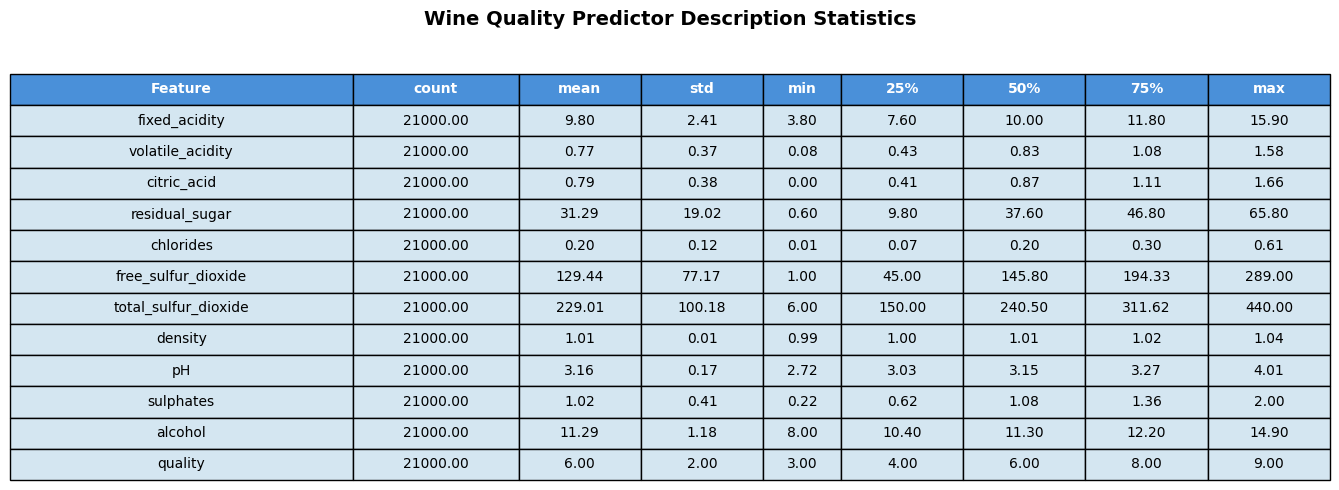

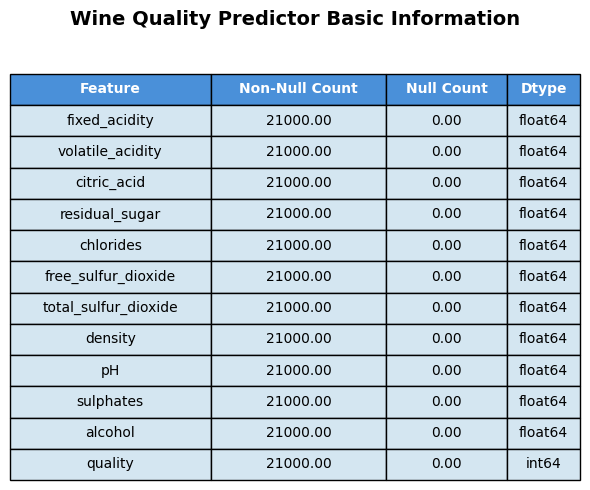

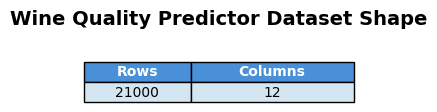


No data to display: Wine Quality Predictor Missing Categorical (String) Data

No data to display: Wine Quality Predictor Missing Numeric Data



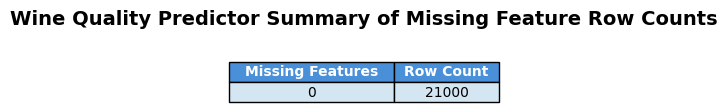

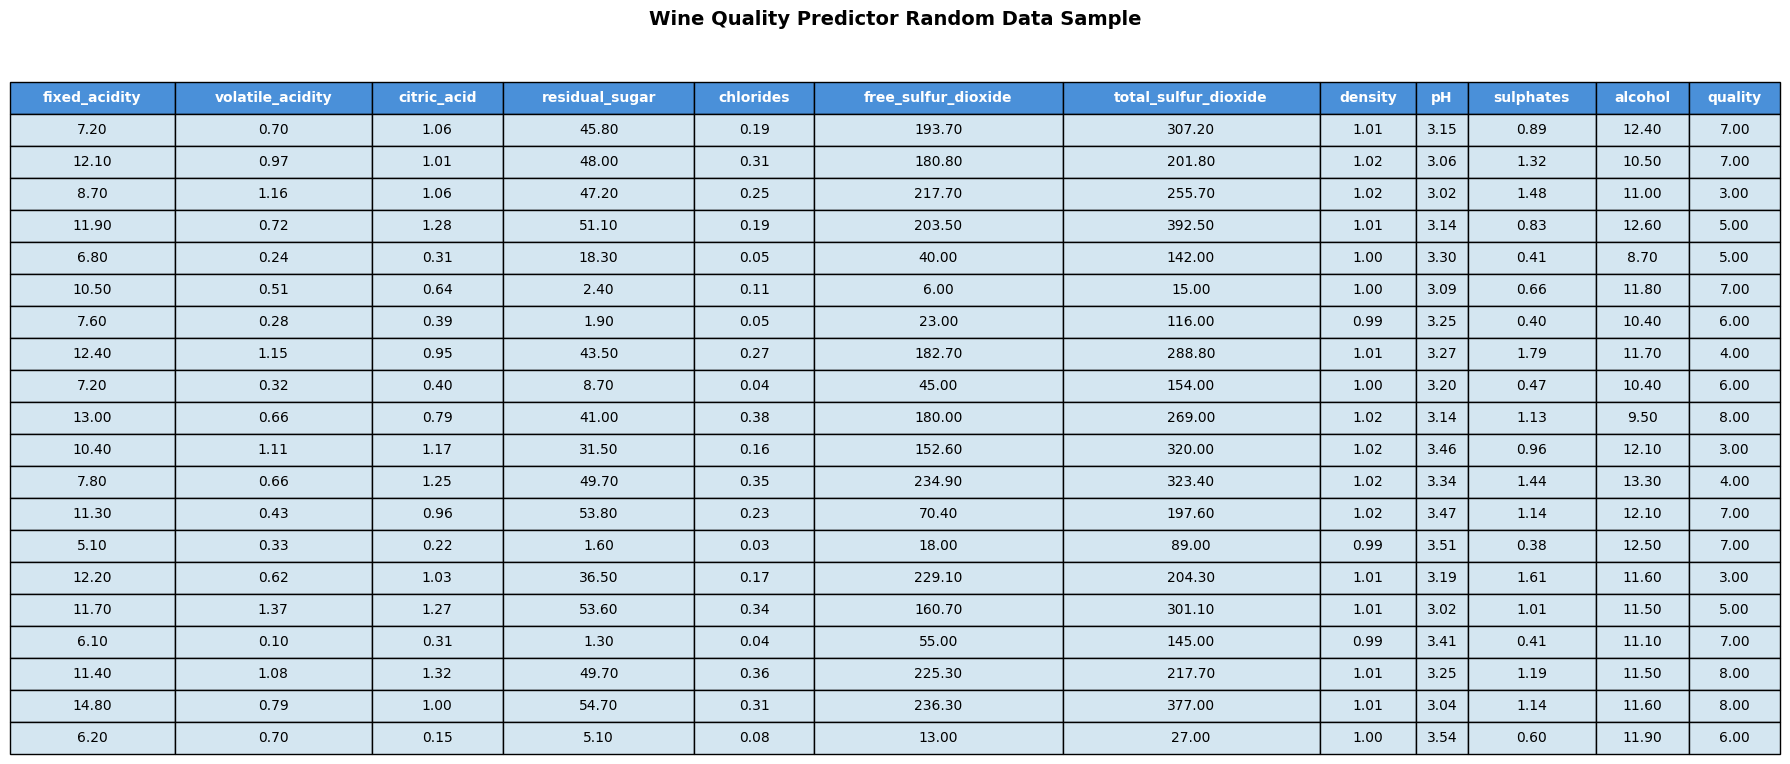

In [784]:
#df_wine.describe()

# Print a fuller initial analysis of the dataset
PrintDataFrameStatus(df_wine)

   ### **Initial Analysis**

1. **More Details Analysis before jumping into model building**
   - Need to perform more initial anlaysis before starting the model building process.
   - Are there missing values - how will they be handled (imputation method)
2. **Visual Analysis**
   - Use Histograms, Boxplots, to get a deeper understanding of the data.
   - Since there are no categorical or binary encoded features, don't need to barplot counts
   

In [785]:
y = df_wine.quality
y

0        3
1        3
2        3
3        3
4        3
        ..
20995    9
20996    9
20997    9
20998    9
20999    9
Name: quality, Length: 21000, dtype: int64

In [786]:
X = df_wine.drop('quality', axis=1)
X

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,11.6,0.580,0.66,2.20,0.074,10.0,47.0,1.00080,3.25,0.57,9.0
1,10.4,0.610,0.49,2.10,0.200,5.0,16.0,0.99940,3.16,0.63,8.4
2,7.4,1.185,0.00,4.25,0.097,5.0,14.0,0.99660,3.63,0.54,10.7
3,10.4,0.440,0.42,1.50,0.145,34.0,48.0,0.99832,3.38,0.86,9.9
4,8.3,1.020,0.02,3.40,0.084,6.0,11.0,0.99892,3.48,0.49,11.0
...,...,...,...,...,...,...,...,...,...,...,...
20995,9.7,1.020,0.91,50.00,0.412,114.6,181.7,1.02085,3.30,0.89,12.0
20996,10.2,0.610,0.88,53.80,0.250,62.4,204.7,1.02776,3.52,1.14,9.7
20997,13.4,0.460,1.04,52.10,0.449,63.0,273.5,1.02618,2.89,1.76,9.3
20998,6.6,1.030,1.09,25.30,0.138,179.8,295.0,1.02476,2.94,1.54,12.9


In [787]:
from sklearn.preprocessing import MinMaxScaler

mm_scaler = MinMaxScaler(feature_range=(-1, 1))

X = mm_scaler.fit_transform(X)
X = pd.DataFrame(data=X, columns=df_wine.drop('quality', axis=1).columns)
X

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,0.289256,-0.333333,-0.204819,-0.950920,-0.784053,-0.937500,-0.811060,-0.472142,-0.178295,-0.606742,-0.710145
1,0.090909,-0.293333,-0.409639,-0.953988,-0.365449,-0.972222,-0.953917,-0.526123,-0.317829,-0.539326,-0.884058
2,-0.404959,0.473333,-1.000000,-0.888037,-0.707641,-0.972222,-0.963134,-0.634085,0.410853,-0.640449,-0.217391
3,0.090909,-0.520000,-0.493976,-0.972393,-0.548173,-0.770833,-0.806452,-0.567766,0.023256,-0.280899,-0.449275
4,-0.256198,0.253333,-0.975904,-0.914110,-0.750831,-0.965278,-0.976959,-0.544631,0.178295,-0.696629,-0.130435
...,...,...,...,...,...,...,...,...,...,...,...
20995,-0.024793,0.253333,0.096386,0.515337,0.338870,-0.211111,-0.190323,0.300945,-0.100775,-0.247191,0.159420
20996,0.057851,-0.293333,0.060241,0.631902,-0.199336,-0.573611,-0.084332,0.567380,0.240310,0.033708,-0.507246
20997,0.586777,-0.493333,0.253012,0.579755,0.461794,-0.569444,0.232719,0.506458,-0.736434,0.730337,-0.623188
20998,-0.537190,0.266667,0.313253,-0.242331,-0.571429,0.241667,0.331797,0.451706,-0.658915,0.483146,0.420290


   ### **Scaling and Leakage**

1. **Applying Scalling Now?**
   - Scaling is done too early in the process here.
   - Through EDA - check for:
      - Distribution - do any normalization strategies need to be applied?
      - Skewness
      - Outliers - Are there outliers, how should they be handled?
   - Once you've done full EDA, made the appropriate modifications, run the model and see how it performs
   - Then apply scaling to see what those results look like compared to previous runs.
   - You should really get a baseline run of the raw data and use that as a comparison point to see if and how much you are improving your model.
2. **Scaling and Data Leakage**
   - Scaling is being applied against the entire feature set
   - To avoid leakge, scaling should be fit against the training data and then have the transform performed against test/train
      - X_train_scaled = scaler.transform(X_train)
      - X_test_scaled = scaler.transform(X_test)
   - Then use these when running the model.
   

In [788]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle=True, random_state=1)

print('Shape of X_train: ', X_train.shape)
print('Shape of X_test: ',X_test.shape)
print('Shape of y_train: ',y_train.shape)
print('Shape of y_test: ',y_test.shape)

Shape of X_train:  (16800, 11)
Shape of X_test:  (4200, 11)
Shape of y_train:  (16800,)
Shape of y_test:  (4200,)


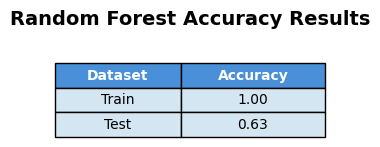

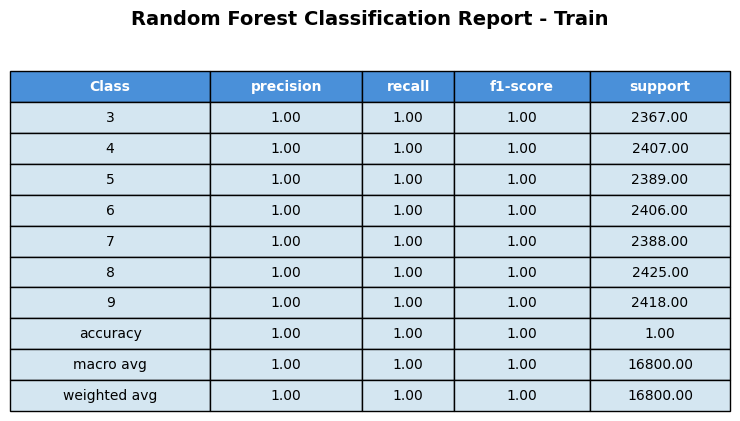

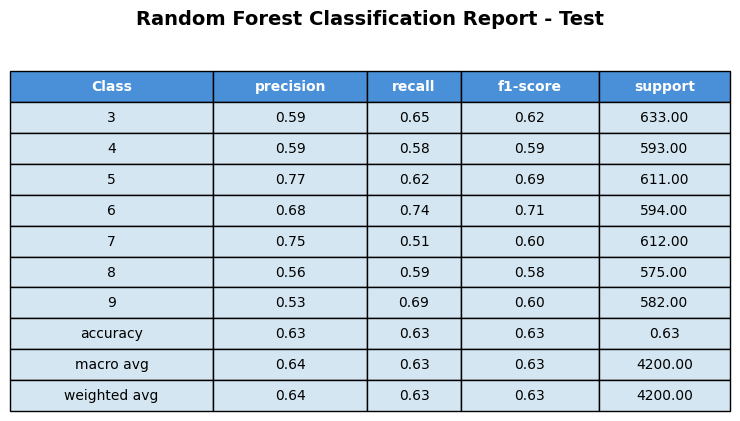

In [789]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Initialize and train a RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Evaluate accuracy
# Evaluate accuracy using the accuracy_score function from sklearn
df_results = pd.DataFrame({
                            'Dataset': ['Train', 'Test'],
                            'Accuracy': [
                                accuracy_score(y_train, y_train_pred),
                                accuracy_score(y_test, y_test_pred)
                            ]
                        })

DisplayTable(df_results, table_title='Random Forest Accuracy Results')

# print the classification_report for your logistic regressor
train_report = classification_report(y_train, y_train_pred, output_dict=True)
df_train = pd.DataFrame(train_report).T.reset_index().rename(columns={'index': 'Class'})
DisplayTable(df_train, table_title='Random Forest Classification Report - Train')

test_report = classification_report(y_test, y_test_pred, output_dict=True)
df_test = pd.DataFrame(test_report).T.reset_index().rename(columns={'index': 'Class'})
DisplayTable(df_test, table_title='Random Forest Classification Report - Test')

   ### **Random Forest Model**
   Since this is a classification problem we're trying to solve using the RandomForestClassifier is the correct choice of models

1. **Jumping right to Random Forest?**
   - Random Forest can be expensive in terms of processing performance.
   - Before jumping right to Random Forest, other models should be considered:
        - Logistic Regression
        - KNN
        - Decision Tree        
   - This will give you some results to compare against to determine the best model.
   
2. **Accuracy Score**
   - Accuracy score on it's own is not a good indicator of model performance.
   - It can be misleading
   

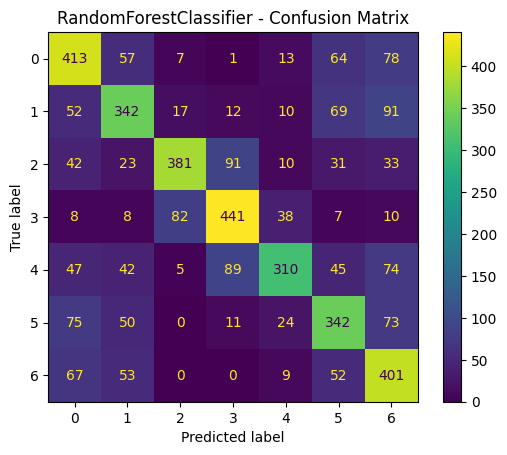

In [790]:
# Calculate the confusion matrix by passing the true y lables, and the predicted y lables
cm = confusion_matrix(y_test, y_pred)

# Use the ConfusionMatrixDisplay from skelearn to get a quick and easy graph
ConfusionMatrixDisplay(cm).plot()
plt.title('RandomForestClassifier - Confusion Matrix')
plt.show()

### Multiclass Classifier Questions
1. Summarize the steps I took to create this multiclass classifier

   - Read in dataset from csv file
   - Identify target label for classification
   - Examine target label values
   - Drop target label from dataframe
   - Apply scaling to entire dataset (before splitting)
   - Apply RandomForest model for classification before considering other less expensive/complicated model solutions
   - Examine results - Accuracy, Classification Report, Confusion Matrix
2. Interpret the Confusion Matrix and Classification Report
   - Class 5 (C5) had the highest precision (right 77%)
   - C7 has high precision, but lowest recall
   - Honestly, I'm having a hard time understanding the classification metrics and confusion matrix and what these really show about the results.
3. How could we improve this model? Be specific.
   - More Feature Engineering
      - Analyze/normalize distributions?
      - Binning - investigate if that will help performance
      - Combine features to create new ones
      - Potentially Polynomial Feature creation
   - Hyperparameter tuning using GridSearchCV() to determine optimum parameters for the random forest
4. What other models might be good to solve this problem?
      - Logistic Regression
      - Decision Tree
      - KNN
      - Naive Bayes
5. What are the potential downsides of solving this as a classification problem?
   - There's no degrees of scale when the prediction is wrong.
      - If the expected result is 2, getting a prediction of 4 vs 7 is just as wrong
      - You don't know how wrong you are.
6. What are the benefits of solving this as a classification problem?
   - Simpler/easier to interpret the results because the results are essentially in buckets
   

# 3. Binary Classification - Cure The Princess
## https://www.kaggle.com/datasets/unmoved/cure-the-princess

In [791]:
df_Quest = pd.read_csv('Cure_the_princess.csv')
df_Quest

,Phoenix Feather,Unicorn Horn,Dragon's Blood,Mermaid Tears,Fairy Dust,Goblin Toes,Witch's Brew,Griffin Claw,Troll Hair,Kraken Ink,Minotaur Horn,Basilisk Scale,Chimera Fang,Cured
0,2.4,18.7,18.4,27.9,7.9,9.6,18.3,13.2,2.5,26.0,10.5,26.2,12.5,0
1,2.1,6.0,15.0,13.3,15.6,13.1,11.0,5.0,7.2,26.0,1.5,13.3,6.2,0
2,17.2,13.9,23.8,6.8,10.7,15.8,19.4,2.7,15.4,21.2,11.1,16.6,11.4,1
3,8.4,9.7,6.8,26.9,4.6,29.1,14.6,19.7,18.0,20.8,13.6,13.9,8.1,1
4,22.1,10.8,16.4,10.5,22.0,23.4,2.6,18.2,23.8,11.3,5.5,16.8,16.2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2333,9.4,2.2,15.8,5.9,29.7,18.7,11.5,13.1,15.3,22.5,10.1,4.7,13.8,0
2334,12.1,7.6,20.6,5.3,18.9,19.1,9.4,11.9,21.8,12.0,26.7,8.4,24.4,1
2335,15.2,33.2,7.2,14.5,16.0,16.7,1.2,32.5,34.5,25.9,3.9,18.0,19.2,1
2336,2.0,17.0,33.2,13.2,29.1,35.5,19.7,30.3,30.7,4.3,15.7,20.5,2.1,1


***********************************
Description Stats
***********************************

            Feature   count       mean       std  min    25%   50%     75%  \
0   Phoenix Feather  2338.0  15.365697  8.669969  1.0  8.500  14.7  21.300   
1      Unicorn Horn  2338.0  10.946749  7.225162  1.0  5.300   9.5  15.575   
2    Dragon's Blood  2338.0  16.115654  8.372518  1.0  9.600  15.8  22.000   
3     Mermaid Tears  2338.0  13.627973  7.545244  1.0  7.600  13.1  19.000   
4        Fairy Dust  2338.0  15.069504  8.349340  1.0  8.625  14.5  20.700   
5       Goblin Toes  2338.0  14.157271  7.831476  1.0  7.900  13.5  19.500   
6      Witch's Brew  2338.0  12.328914  7.709753  1.0  6.325  11.2  16.900   
7      Griffin Claw  2338.0  14.911206  8.132678  1.0  8.400  14.4  20.500   
8        Troll Hair  2338.0  16.871685  9.579027  1.0  8.900  16.3  24.000   
9        Kraken Ink  2338.0  14.890590  8.014197  1.0  8.800  14.4  20.400   
10    Minotaur Horn  2338.0  10.916125  7.045195  1

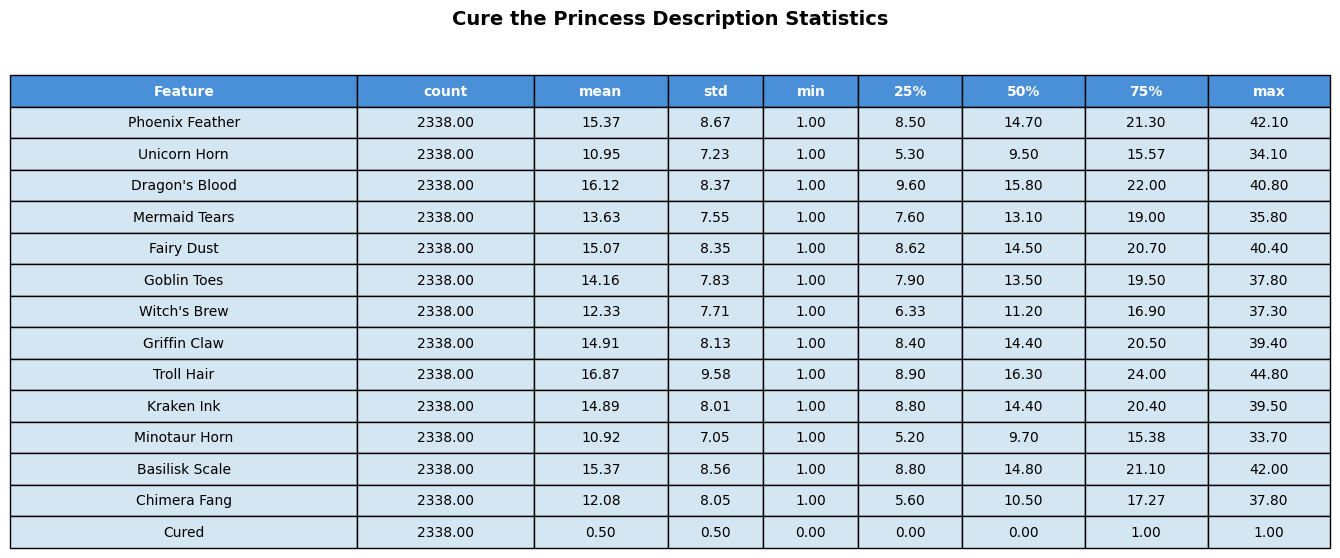

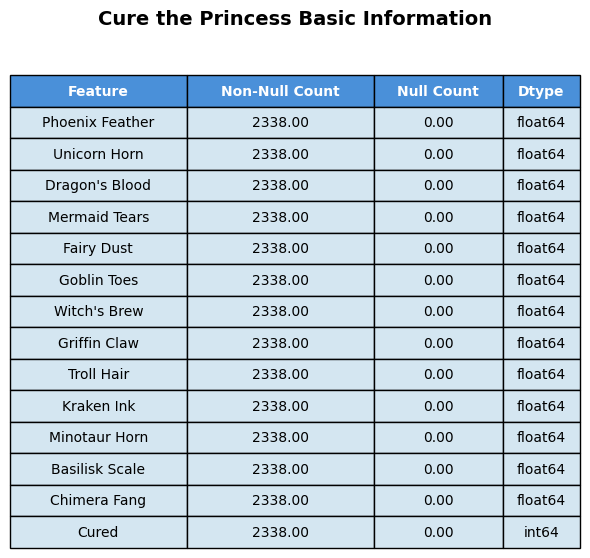

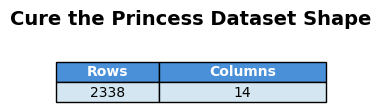


No data to display: Cure the Princess Missing Categorical (String) Data

No data to display: Cure the Princess Missing Numeric Data



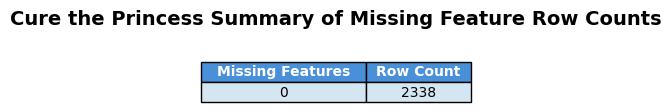

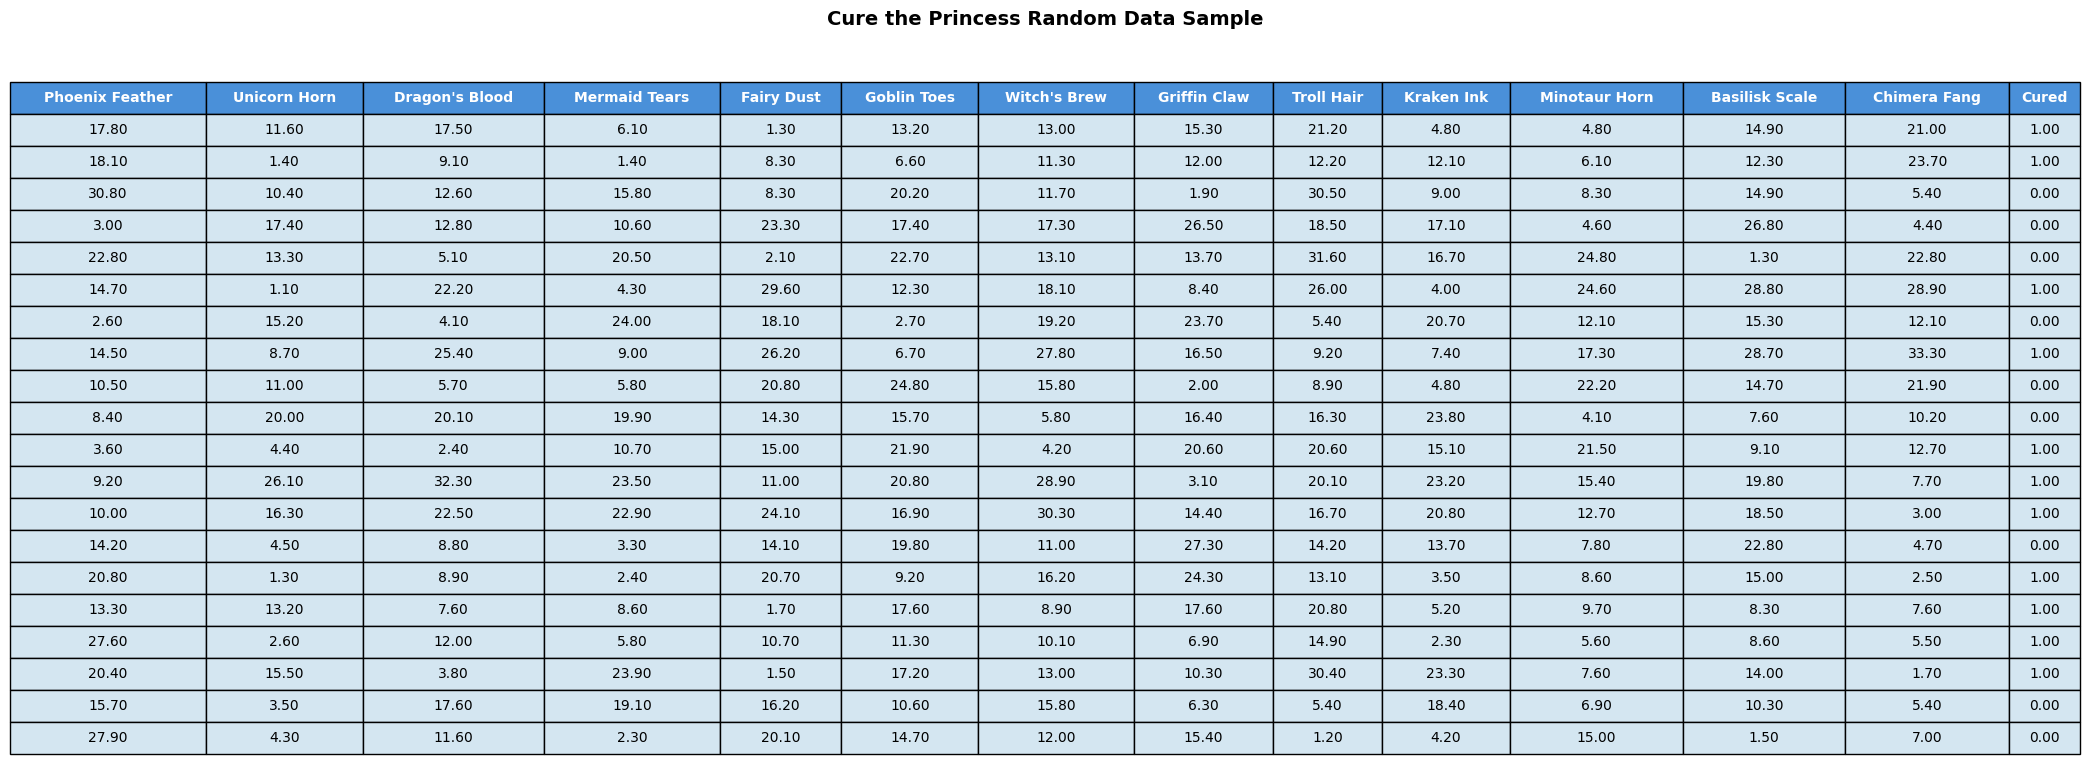

In [792]:
# Envoke the describe command on the dataset
data_set_name = 'Cure the Princess'
target_label = 'Cured'

PrintDataFrameStatus(df_Quest)


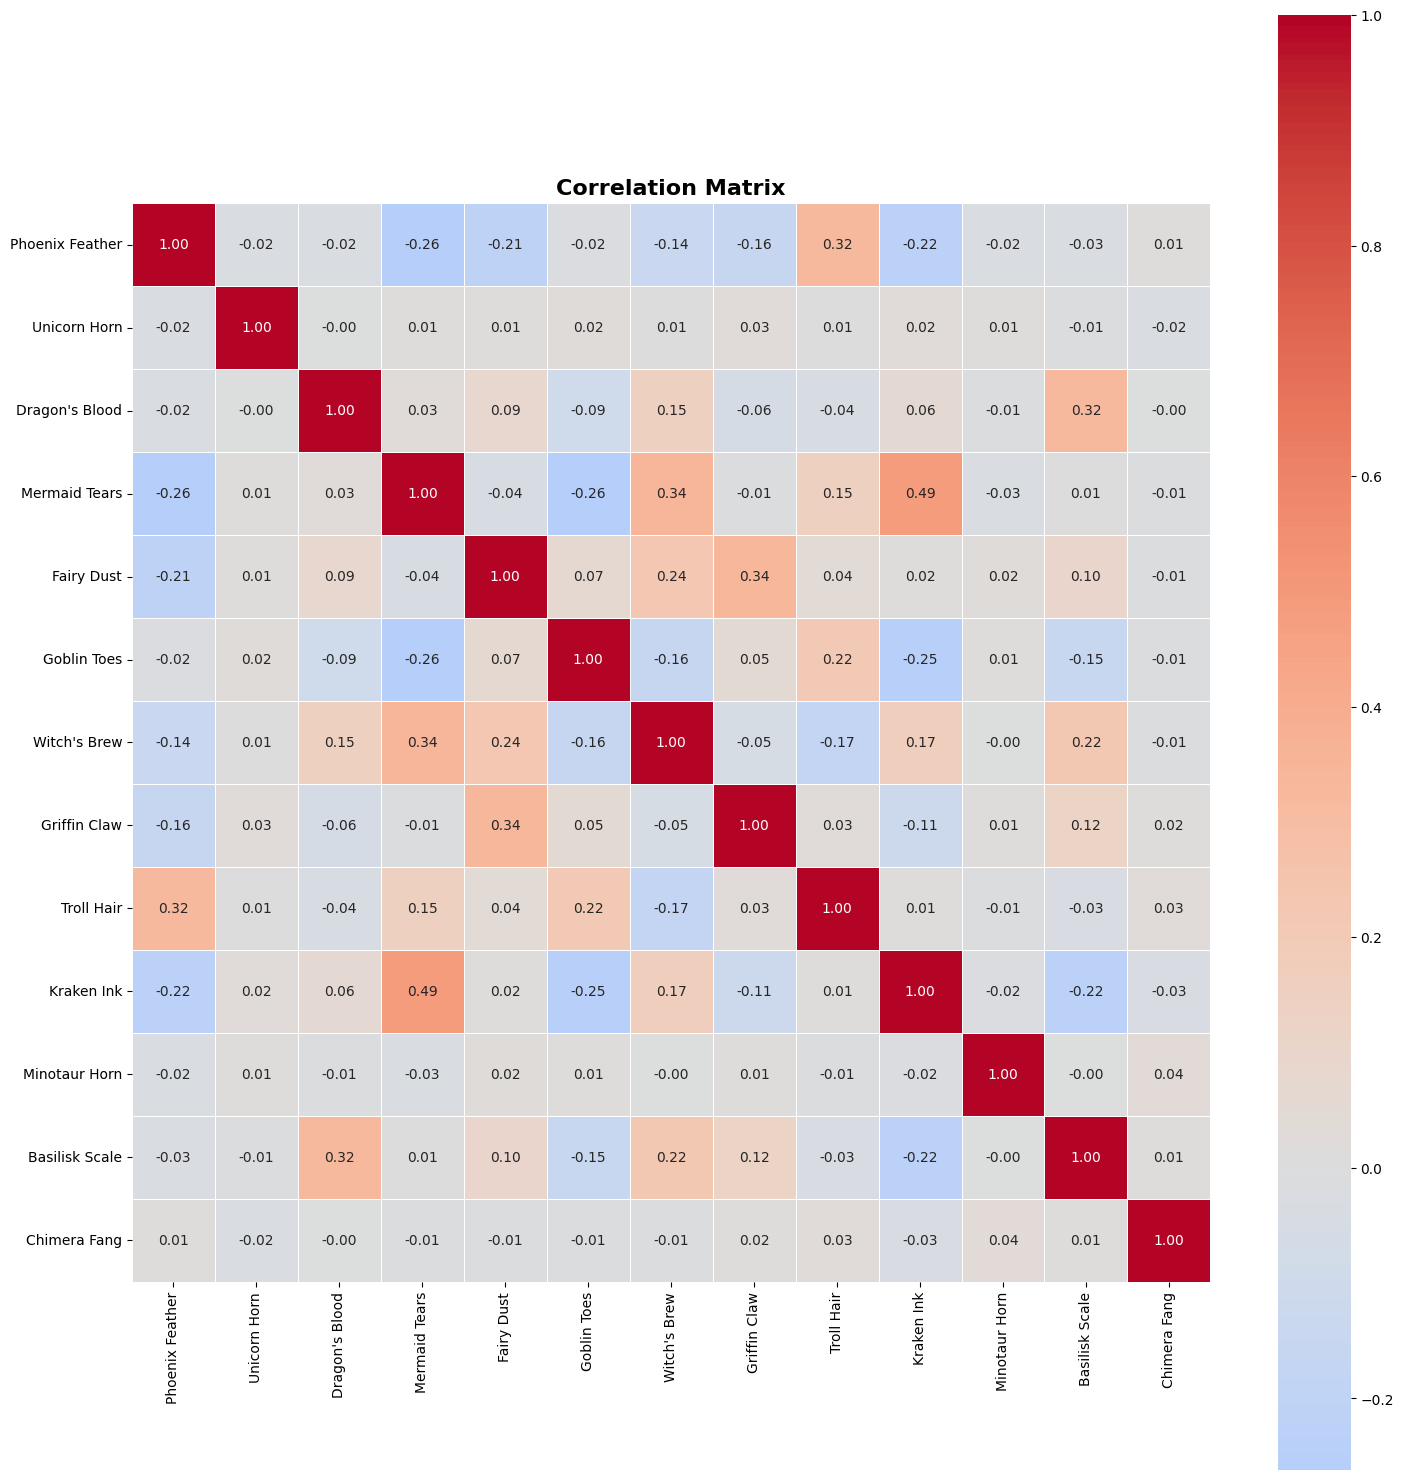

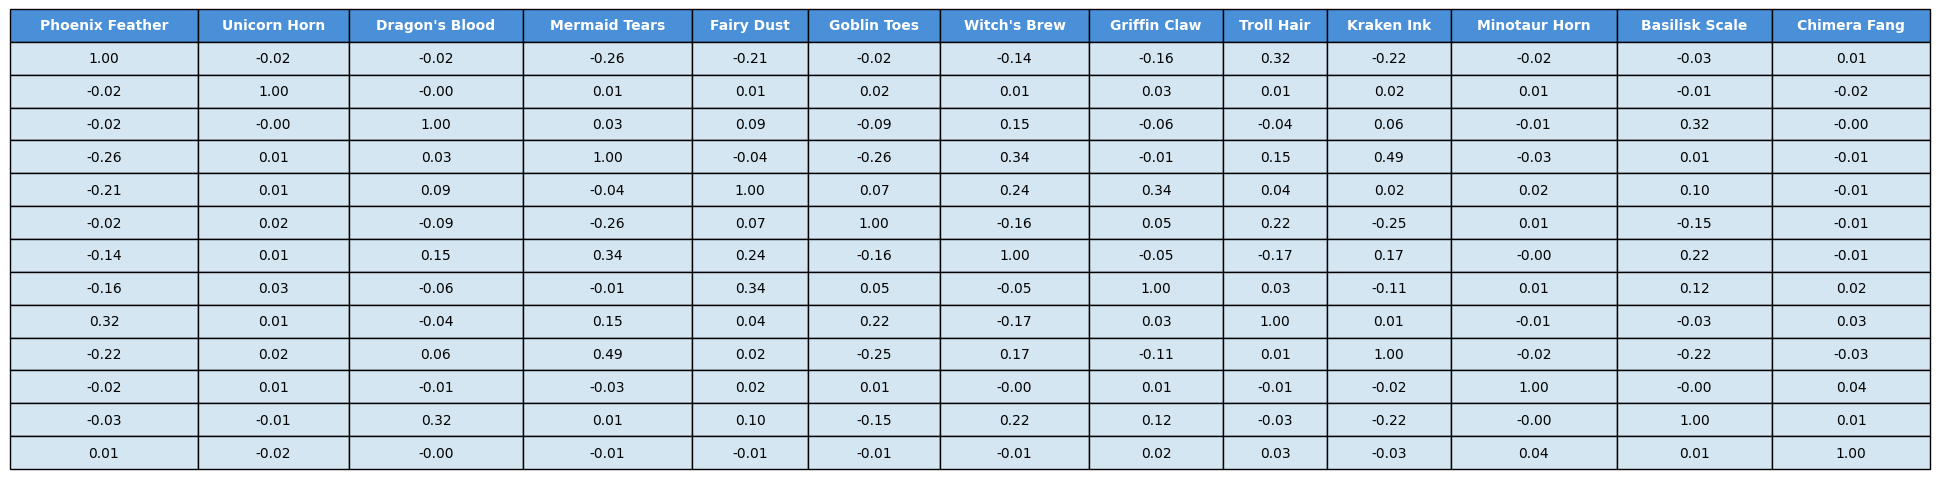

In [793]:
# Plot the values from the .corr() command on a heat map
DisplayCorrelationInfo(df_Quest, target_label=target_label, plot_title='Cure The Princess')


In [794]:
# Seperate your ingredients (features) from the outcome (target)
X = df_Quest.drop('Cured', axis=1)
X

,Phoenix Feather,Unicorn Horn,Dragon's Blood,Mermaid Tears,Fairy Dust,Goblin Toes,Witch's Brew,Griffin Claw,Troll Hair,Kraken Ink,Minotaur Horn,Basilisk Scale,Chimera Fang
0,2.4,18.7,18.4,27.9,7.9,9.6,18.3,13.2,2.5,26.0,10.5,26.2,12.5
1,2.1,6.0,15.0,13.3,15.6,13.1,11.0,5.0,7.2,26.0,1.5,13.3,6.2
2,17.2,13.9,23.8,6.8,10.7,15.8,19.4,2.7,15.4,21.2,11.1,16.6,11.4
3,8.4,9.7,6.8,26.9,4.6,29.1,14.6,19.7,18.0,20.8,13.6,13.9,8.1
4,22.1,10.8,16.4,10.5,22.0,23.4,2.6,18.2,23.8,11.3,5.5,16.8,16.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2333,9.4,2.2,15.8,5.9,29.7,18.7,11.5,13.1,15.3,22.5,10.1,4.7,13.8
2334,12.1,7.6,20.6,5.3,18.9,19.1,9.4,11.9,21.8,12.0,26.7,8.4,24.4
2335,15.2,33.2,7.2,14.5,16.0,16.7,1.2,32.5,34.5,25.9,3.9,18.0,19.2
2336,2.0,17.0,33.2,13.2,29.1,35.5,19.7,30.3,30.7,4.3,15.7,20.5,2.1


In [795]:
# Separate out Cured (target)
y = df_Quest.Cured
y

0       0
1       0
2       1
3       1
4       0
       ..
2333    0
2334    1
2335    1
2336    1
2337    1
Name: Cured, Length: 2338, dtype: int64

In [796]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=315)

# Initalize the MinMaxScaler with feature_range=(-1, 1)
scaler = MinMaxScaler(feature_range=(-1, 1))

# Transform the Ingredients (X) using the MinMaxScaler
X_train_scaled = scaler.fit_transform(X_train)  # Learns from training only
X_test_scaled = scaler.transform(X_test) 


   ### **Train/Test Splitting and Applying Scaling**
   Again we're circumventing the interative process of trying which model is best and assuming Binary is the best. </br>
   More detail EDA and Feature Engineering (distribution, skewness, outliers and normalization)

1. **Train/Test split**
   - Standard pattern for train/test split of data
   
2. **Scaling**
   - Scaling is correctly applied after the trest/train split to avoid data leakage issues.
   

In [797]:
# Separate the training and testing data using the train_test_split function


# print the shape of your datasets
print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (1870, 13)
Shape of X_test: (468, 13)
Shape of y_train: (1870,)
Shape of y_test: (468,)


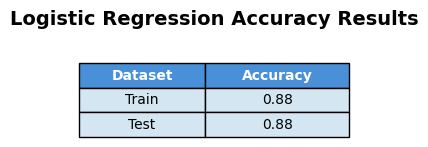

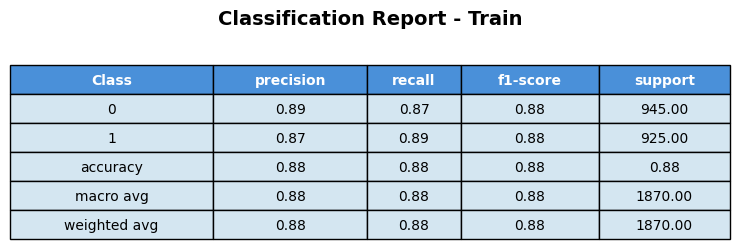

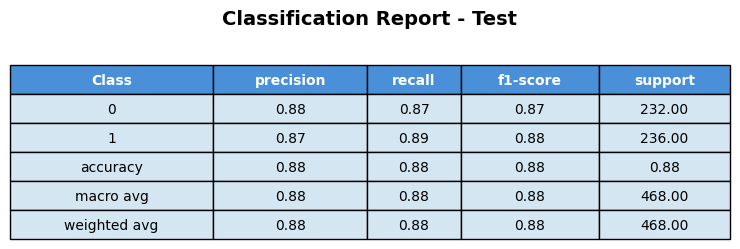

In [798]:
# Import Statements
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, roc_auc_score, RocCurveDisplay

# Initialize and train a LogisticRegressior
model = LogisticRegression()

model.fit(X_train_scaled, y_train)

# Make class predictions 
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Make probability predicitons, named y_proba
y_train_proba = model.predict_proba(X_train_scaled)
y_test_proba = model.predict_proba(X_test_scaled)

# Evaluate accuracy using the accuracy_score function from sklearn
df_results = pd.DataFrame({
                            'Dataset': ['Train', 'Test'],
                            'Accuracy': [
                                accuracy_score(y_train, y_train_pred),
                                accuracy_score(y_test, y_test_pred)
                            ]
                        })

DisplayTable(df_results, table_title='Logistic Regression Accuracy Results')

# print the classification_report for your logistic regressor
results = classification_report(y_train, y_train_pred, output_dict=True)
df_train = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Class'})
DisplayTable(df_train, table_title='Classification Report - Train')

# Test report
results  = classification_report(y_test, y_test_pred, output_dict=True)
df_test = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Class'})
DisplayTable(df_test, table_title='Classification Report - Test')


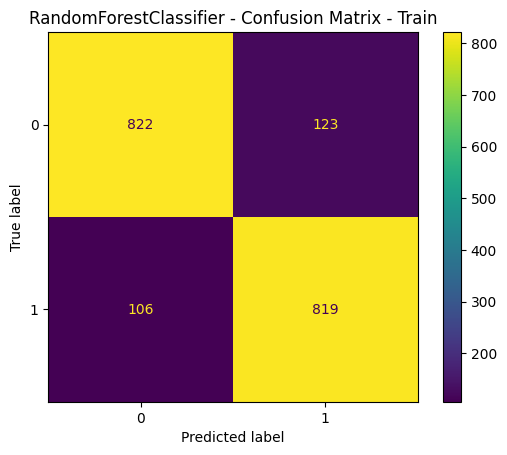

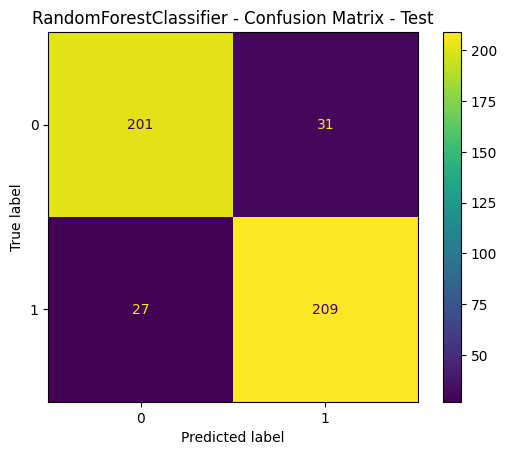

In [799]:
# Create a confusion matrix using the confusion_matrix function, and save it to a variable named cm

# Calculate the confusion matrix by passing the true y lables, and the predicted y lables
train_cm = confusion_matrix(y_train, y_train_pred)
test_cm = confusion_matrix(y_test, y_test_pred)

# Use the ConfusionMatrixDisplay from skelearn to get a quick and easy graph
ConfusionMatrixDisplay(train_cm).plot()
plt.title('RandomForestClassifier - Confusion Matrix - Train')
plt.show()

ConfusionMatrixDisplay(test_cm).plot()
plt.title('RandomForestClassifier - Confusion Matrix - Test')
plt.show()


In [800]:
# use the (receiver operating characteristic) roc_curve function to calculate the falsepositive_rate, truepositive_rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba[:, 1])

# use the roc_auc_score to calculate the Area Under the Curve (AUC)
auc = roc_auc_score(y_test, y_test_proba[:, 1])

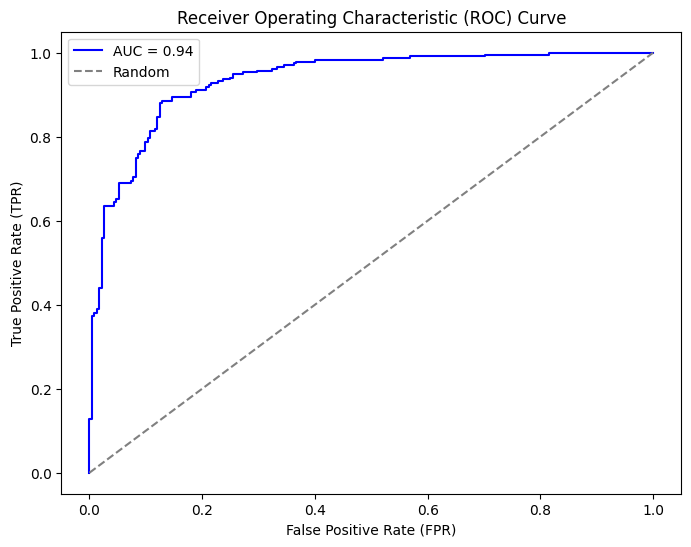

In [801]:
# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(False)
plt.show()

### Cure the Princess

#### **Ran out of time for this section. I will revisit over the weekend** ####
1. What ingredients should you use?
2. How can you be certain that these are the correct ingredients?
3. Can you determine the **exact ratio** of ingredients that maximizes the princess' survival?
4. Should attempt to convience the king that you know to cure the princess, or should you conduct more experiments?
5. *Assuming* that you are ready to cure the princess, convince the king.